In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('../dsbdaldatasets/Social_Network_Ads.csv', low_memory = False)

In [3]:
df.shape

(400, 5)

In [4]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df.Purchased.value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [6]:
df.Gender.value_counts()

Gender
Female    204
Male      196
Name: count, dtype: int64

In [7]:
df.dtypes

User ID            int64
Gender               str
Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object

In [8]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [9]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


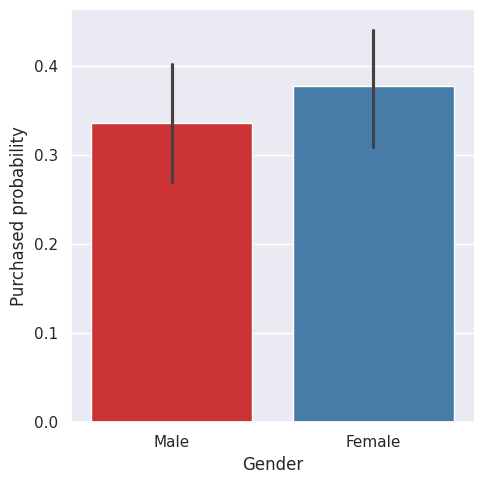

In [10]:
sns.set_theme(style='darkgrid',palette='Set1')
cat = sns.catplot(x = 'Gender' , y = 'Purchased' , data = df , 
                  kind = 'bar' , height = 5 , hue='Gender')
cat.set_ylabels('Purchased probability')
plt.show()

Purchased         0         1
Gender                       
Female     0.622549  0.377451
Male       0.663265  0.336735


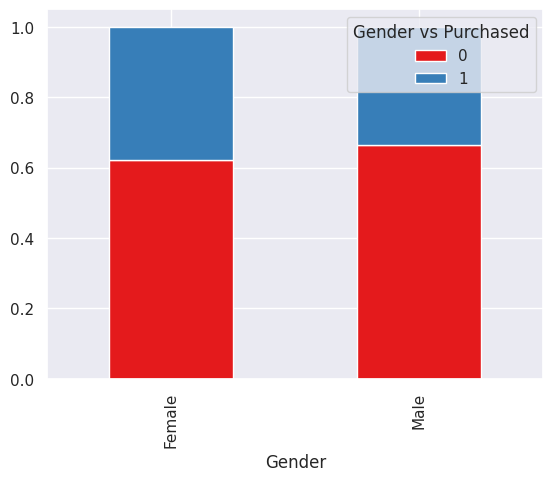

In [11]:
cross = pd.crosstab(df.Gender,df.Purchased,normalize='index')
print(cross)
cross.plot.bar(stacked=True)
plt.legend(title='Gender vs Purchased' , loc = 'upper right')
plt.show()

In [12]:
df.drop('User ID',axis=1,inplace=True)

(3, 3)


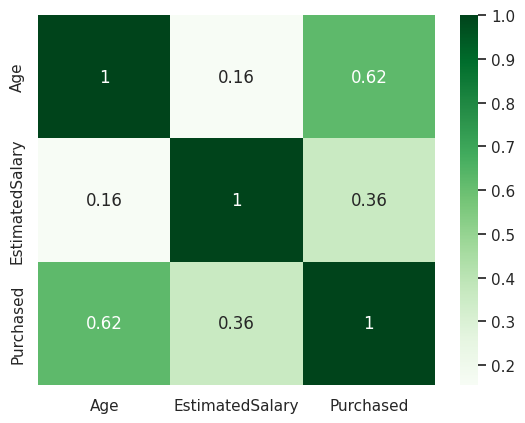

In [13]:
corr = df.select_dtypes(include=['float64','int64']).corr()
print(corr.shape)
sns.heatmap(data=corr, annot = True , cmap='Greens')
plt.show()

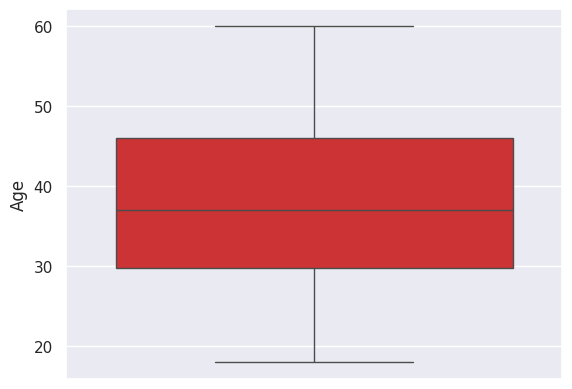

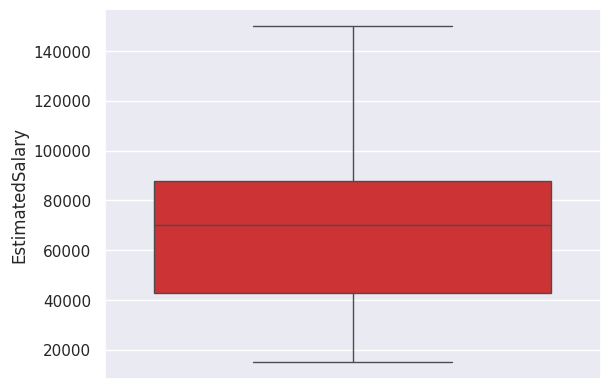

In [14]:
sns.boxplot(df.Age)
plt.show()
sns.boxplot(df.EstimatedSalary)
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

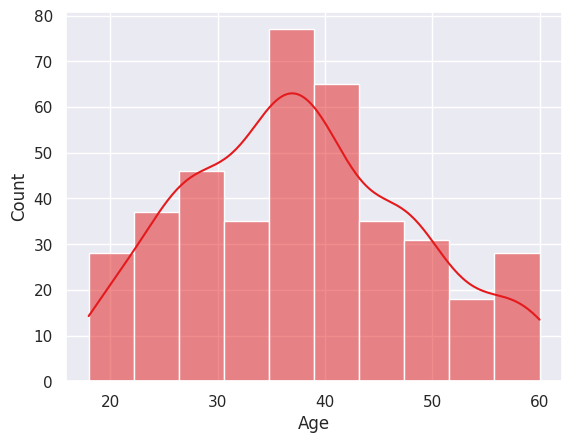

In [15]:
sns.histplot(df.Age,kde=True)

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

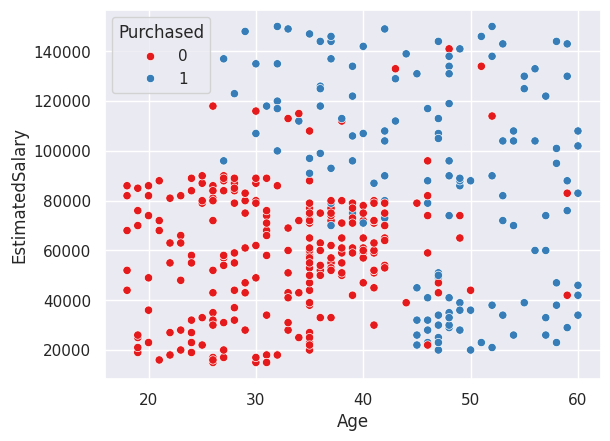

In [16]:
sns.scatterplot(data=df,x=df.Age, y=df.EstimatedSalary,hue='Purchased')

In [17]:
df

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


In [18]:
x = df.drop(columns={'Gender','Purchased'})
y = df['Purchased']

In [19]:
from sklearn.model_selection import train_test_split

x_train , x_test, y_train , y_test = train_test_split(x,y,train_size=0.8,random_state=42)

In [20]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
print(model.score(x_train,y_train)*100)

83.75


In [21]:
model.score(x_test,y_test)*100

88.75

In [22]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x_test)
print(accuracy_score(y_pred,y_test)*100)

88.75


In [23]:
sx_train , sx_test, sy_train , sy_test = train_test_split(x,y,train_size=0.8,random_state=42)
from sklearn.preprocessing import StandardScaler
stdsc = StandardScaler()
sx_train = stdsc.fit_transform(sx_train)
sx_test = stdsc.transform(sx_test)

In [24]:
from sklearn.linear_model import LogisticRegression
smodel = LogisticRegression()
smodel.fit(sx_train,sy_train)
print(smodel.score(sx_train,sy_train)*100)
print(smodel.score(sx_test,sy_test)*100)
sy_pred= smodel.predict(sx_test)
print(accuracy_score(sy_pred,sy_test)*100)

84.0625
86.25
86.25


In [25]:
from sklearn.metrics import confusion_matrix
cmat = confusion_matrix(y_test,y_pred)
print(cmat)

[[50  2]
 [ 7 21]]


In [26]:
from sklearn.metrics import precision_recall_fscore_support
prfs = precision_recall_fscore_support(y_test,y_pred)
print(prfs[0])
print(prfs[1])
print(prfs[2])
print(prfs[3])

[0.87719298 0.91304348]
[0.96153846 0.75      ]
[0.91743119 0.82352941]
[52 28]


In [27]:
from sklearn.metrics import classification_report
clssrep = classification_report(y_test,y_pred)
print(clssrep)

              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



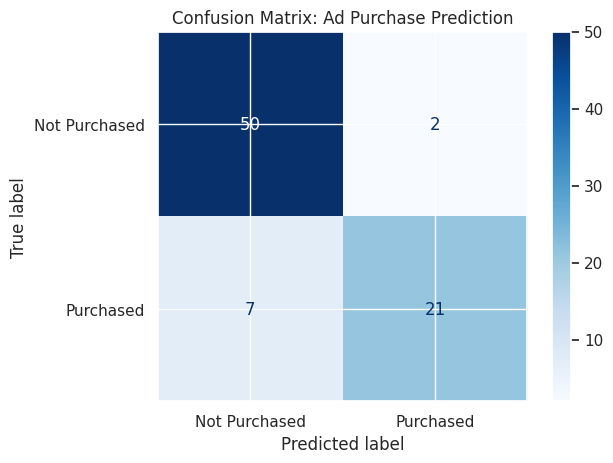

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

cmatdisplay = ConfusionMatrixDisplay.from_estimator(
                model,
                x_test,
                y_test,
                cmap = 'Blues',
                display_labels=['Not Purchased', 'Purchased']
)

# Optional: Add a title
plt.title('Confusion Matrix: Ad Purchase Prediction')
plt.show()        

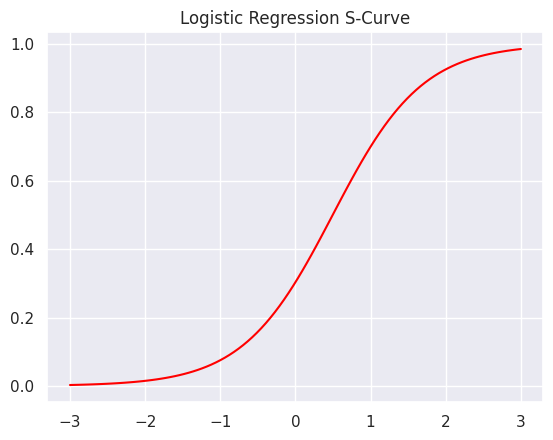

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get a smooth range of numbers for the X-axis
# (Use 100 points between -3 and 3 for scaled data)
x_range = np.linspace(-3, 3, 100).reshape(-1, 1)

# 2. Get the Probabilities (The S-Curve)
# [:, 1] gives the probability of 'Purchased' (Class 1)
y_probs = smodel.predict_proba(x_range)[:, 1]

# 3. Plot
plt.plot(x_range, y_probs, color='red', label='Sigmoid Curve')
plt.title("Logistic Regression S-Curve")
plt.show()
